In [51]:
from pynq import Overlay

ol = Overlay("./design_1_wrapper.bit")

In [26]:
ol.dma?

In [2]:
IP_BASE_ADDR = 0x4000_0000
ADDR_RANGE = 0x0FFF

In [52]:
from pynq import MMIO
mmio = MMIO(IP_BASE_ADDR, ADDR_RANGE)

Test read from STATUS register

In [118]:
ADDR_OFFSET = 0x08
result = mmio.read(ADDR_OFFSET)
print(result)

2


In [54]:
dma = ol.dma
dma_send = ol.dma.sendchannel
dma_recv = ol.dma.recvchannel

In [6]:
from pynq import allocate
import numpy as np
import math

import numpy as np

try:
    import matplotlib.pyplot as plt              # headless-safe: mpl falls back to Agg
except Exception:                                 # plotting optional
    plt = None

In [7]:
# ---------------------------------------------------------------------------
# fixed-point word / stream layout
# ---------------------------------------------------------------------------
WORD_BITS = 18          # s2.16 data word
FRAC_BITS = 16
IM_SHIFT  = 18          # bit position of im within the 64-bit beat ({'0,im,re})

_CODE_MIN = -(1 << (WORD_BITS - 1))
_CODE_MAX = (1 << (WORD_BITS - 1)) - 1
_MASK     = (1 << WORD_BITS) - 1


def quantize(x):
    """Complex float -> integer s2.16 codes (round-to-nearest, saturating)."""
    re = np.clip(np.round(np.real(x) * 2.0 ** FRAC_BITS), _CODE_MIN, _CODE_MAX)
    im = np.clip(np.round(np.imag(x) * 2.0 ** FRAC_BITS), _CODE_MIN, _CODE_MAX)
    return re.astype(np.int64), im.astype(np.int64)


def pack(x):
    """Complex float samples -> uint64 stream beats ({'0, im, re})."""
    re, im = quantize(x)
    return (((im & _MASK) << IM_SHIFT) | (re & _MASK)).astype(np.uint64)


def unpack(beats):
    """uint64 stream beats -> complex float samples (sign-extended codes)."""
    beats = np.asarray(beats, dtype=np.uint64)
    re = (beats & _MASK).astype(np.int64)
    im = ((beats >> IM_SHIFT) & _MASK).astype(np.int64)
    sign = 1 << (WORD_BITS - 1)
    re = (re ^ sign) - sign
    im = (im ^ sign) - sign
    return (re + 1j * im) * 2.0 ** -FRAC_BITS

# ---------------------------------------------------------------------------
# configuration mapping: FFT length N <-> CONFIG_SEL register value
# ---------------------------------------------------------------------------
FFT_SIZE_BASE = 12          # c_fft_size_base in mr_fft_pkg.vhd
MAX_FFT_SIZE  = 3300        # c_max_fft_size


def supported_sizes():
    """All supported FFT lengths, ascending -- IDENTICAL to the RTL's
    c_fft_sizes table (f_fft_sizes sorts ascending: config index = rank of N),
    so list.index(N) IS the CONFIG_SEL register value."""
    sizes, n2 = [], FFT_SIZE_BASE
    while n2 <= MAX_FFT_SIZE:
        n3 = n2
        while n3 <= MAX_FFT_SIZE:
            n5 = n3
            while n5 <= MAX_FFT_SIZE:
                sizes.append(n5)
                n5 *= 5
            n3 *= 3
        n2 *= 2
    return sorted(sizes)


def config_sel(n):
    """CONFIG_SEL register value for FFT length `n` (raises with the list of
    valid lengths if `n` is not a supported configuration)."""
    sizes = supported_sizes()
    try:
        return sizes.index(n)
    except ValueError:
        raise ValueError(f'N={n} is not a supported FFT length; valid: {sizes}') from None


def list_configs():
    """Print the CONFIG_SEL <-> N table with each config's radix factorization
    and scaling (output = X * 2**-shift)."""
    sizes = supported_sizes()
    print(f'{len(sizes)} configurations (CONFIG_SEL -> N):')
    print(f'{"sel":>4} | {"N":>5} | {"radices":<22} | {"stages":>6} | {"2^-shift":>8}')
    print('-' * 60)
    for sel, n in enumerate(sizes):
        radices = factorize(n)
        print(f'{sel:>4} | {n:>5} | {"*".join(map(str, radices)):<22} | '
              f'{len(radices):>6} | 2^-{total_shift(n):<5}')
    return sizes
# ---------------------------------------------------------------------------
# chain output conventions: digit-reversed order + fixed scaling schedule
# ---------------------------------------------------------------------------
def factorize(n):
    """Ascending radix list [2..][3..][5..] -- the chain's processing order."""
    radices, rem = [], n
    for r in (2, 3, 5):
        while rem % r == 0:
            radices.append(r)
            rem //= r
    if rem != 1:
        raise ValueError(f'N={n} is not 2^a*3^b*5^c')
    return radices


def total_shift(n):
    """Sum of per-stage scaling shifts (fixed schedule: 2->1, 3->2, 5->3)."""
    return sum({2: 1, 3: 2, 5: 3}[r] for r in factorize(n))


def digit_reverse_perm(radices):
    """Mixed-radix digit-reverse permutation (clone of model/utils.py)."""
    radices = list(radices)
    n = int(np.prod(radices))
    mult, tmp = [], n
    for r in radices:
        tmp //= r
        mult.append(tmp)
    mult_rev, tmp = [], n
    for r in radices[::-1]:
        tmp //= r
        mult_rev.append(tmp)
    perm = np.empty(n, dtype=np.int64)
    for idx in range(n):
        digits, t = [], idx
        for m in mult:
            digits.append(t // m)
            t %= m
        perm[idx] = sum(m * d for m, d in zip(mult_rev, digits[::-1]))
    return perm


def natural_order(out_frame, n):
    """Reorder one captured output frame into natural bin order."""
    rev = digit_reverse_perm(list(reversed(factorize(n))))
    return np.asarray(out_frame)[rev]


def reference(x, n):
    """Ideal spectrum at the IP's scale: fft(x) * 2**(-total_shift(n))."""
    return np.fft.fft(np.asarray(x)) * 2.0 ** -total_shift(n)

In [99]:
def config_sel_write(n):
    config_sel_idx = config_sel(n)
    ADDR_OFFSET = 0x0C
    COMMIT_REG_ADDR = 0x04
    mmio.write(ADDR_OFFSET, config_sel_idx)
    mmio.write(COMMIT_REG_ADDR, 0x1)
    result = mmio.read(ADDR_OFFSET)
    ACTIVE_FFT_SIZE_ADDR = 0x18
    result = mmio.read(ACTIVE_FFT_SIZE_ADDR)
    assert result == n
    #print(result)

In [88]:
# ---------------------------------------------------------------------------
# test signals (peak <= 0.9 full scale, the chain input contract)
# ---------------------------------------------------------------------------
def make_signal(kind, n, seed=1):
    rng = np.random.default_rng(seed)
    if kind == 'tone':
        # coherent (bin-centered) complex tone at a bin coprime with N: zero
        # leakage, generic twiddle walk -- the spectrum is one clean spike
        k = max(1, n // 7)
        while math.gcd(k, n) != 1:
            k += 1
        idx = np.arange(n)
        return np.sqrt(2) * np.exp(2j * np.pi * k * idx / n)
    if kind == 'qam16':
        pts = np.array([-3, -1, 1, 3], dtype=float) / np.sqrt(10)
        x = pts[rng.integers(0, 4, n)] + 1j * pts[rng.integers(0, 4, n)]
        return x * (0.9 / (np.sqrt(2) * 3 / np.sqrt(10)))   # peak at 0.9
    if kind == 'ramp':
        idx = np.arange(n)
        return ((idx + 1) * 64 - 1j * (idx + 1) * 32) * 2.0 ** -FRAC_BITS
    if kind == 'impulse':
        x = np.zeros(n, dtype=complex)
        x[0] = 0.9
        return x                                            # flat spectrum
    if kind == 'noise':
        return 0.3 * (rng.standard_normal(n) + 1j * rng.standard_normal(n))
    raise ValueError(f'unknown signal kind: {kind}')

In [110]:
# ---------------------------------------------------------------------------
# analysis / plotting
# ---------------------------------------------------------------------------
def analyze(x, captured, n, save=None, title=None):
    """Unpack + reorder one captured frame, plot it against the ideal
    reference and print an SQNR summary. `captured` may be uint64 beats or
    already-unpacked complex samples. Returns (measured_natural, reference)."""
    captured = np.asarray(captured)
    if captured.dtype == np.uint64:
        captured = unpack(captured[:n])
    meas = natural_order(captured[:n], n)
    ref = reference(x, n)

    err = meas - ref
    p_ref = np.sum(np.abs(ref) ** 2)
    p_err = np.sum(np.abs(err) ** 2)
    sqnr = 10 * np.log10(p_ref / p_err) if p_err > 0 else np.inf
    print(f'N={n}: SQNR vs ideal = {sqnr:.2f} dB '
          f'(EVM ~ {100 * 10 ** (-sqnr / 20):.4f}%)')

    if plt is not None:
        eps = 1e-9
        bins = np.arange(n)
        fig, ax = plt.subplots(3, 1, figsize=(12, 9))

        ax[0].plot(bins, np.real(x), color='#0072B2', linewidth=1.2, label='re')
        ax[0].plot(bins, np.imag(x), color='#E69F00', linewidth=1.2, label='im')
        ax[0].set_title(title or f'mr_fft N={n}')
        ax[0].set_ylabel('input (full scale)')
        ax[0].grid(True, alpha=0.3)
        ax[0].legend(loc='best')

        ax[1].plot(bins, 20 * np.log10(np.abs(ref) + eps), color='black',
                   linewidth=1.6, label='ideal (scaled)')
        ax[1].plot(bins, 20 * np.log10(np.abs(meas) + eps), color='#0072B2',
                   linewidth=1.0, label='IP output (reordered)')
        ax[1].set_ylabel('|X| (dB)')
        ax[1].grid(True, alpha=0.3)
        ax[1].legend(loc='best')

        ax[2].plot(bins, 20 * np.log10(np.abs(err) + eps), color='#D55E00',
                   linewidth=1.0, label='|error|')
        ax[2].set_xlabel('bin (natural order)')
        ax[2].set_ylabel('error (dB)')
        ax[2].ticklabel_format(useOffset=False, axis='y')
        ax[2].grid(True, alpha=0.3)
        ax[2].legend(loc='best')

        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=160)
            print(f'plot -> {save}')
        else:
            plt.show()
        plt.close(fig)

    return meas, ref

def save_plot(rows, modes, signal_kind, dtype, scaling, out_path):
    ylabel = ('Tone SNR (dB, tone power / total error power)'
              if signal_kind == 'single_tone' else 'SQNR vs NumPy (dB)')
    fig, ax = plt.subplots(figsize=(12, 5))
    for mode in modes:
        pts = sorted((r['size'], r['sqnr_db']) for r in rows if r['rounding'] == mode)
        color, marker = MODE_STYLE.get(mode, ('#555555', 'x'))
        ax.plot([p[0] for p in pts], [p[1] for p in pts], color=color, marker=marker,
                markersize=6, linewidth=2, label=mode)
    ax.set_xscale('log', base=2)
    sizes = sorted({r['size'] for r in rows})
    ax.set_xticks(sizes)
    ax.set_xticklabels(sizes, rotation=45, fontsize=8)
    ax.minorticks_off()
    ax.set_title(f'SQNR vs FFT size -- datapath rounding sweep ({signal_kind}, {dtype}, {scaling} scaling)')
    ax.set_xlabel('FFT size N')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', title='rounding')
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)

In [10]:
list_configs()

53 configurations (CONFIG_SEL -> N):
 sel |     N | radices                | stages | 2^-shift
------------------------------------------------------------
   0 |    12 | 2*2*3                  |      3 | 2^-4    
   1 |    24 | 2*2*2*3                |      4 | 2^-5    
   2 |    36 | 2*2*3*3                |      4 | 2^-6    
   3 |    48 | 2*2*2*2*3              |      5 | 2^-6    
   4 |    60 | 2*2*3*5                |      4 | 2^-7    
   5 |    72 | 2*2*2*3*3              |      5 | 2^-7    
   6 |    96 | 2*2*2*2*2*3            |      6 | 2^-7    
   7 |   108 | 2*2*3*3*3              |      5 | 2^-8    
   8 |   120 | 2*2*2*3*5              |      5 | 2^-8    
   9 |   144 | 2*2*2*2*3*3            |      6 | 2^-8    
  10 |   180 | 2*2*3*3*5              |      5 | 2^-9    
  11 |   192 | 2*2*2*2*2*2*3          |      7 | 2^-8    
  12 |   216 | 2*2*2*3*3*3            |      6 | 2^-9    
  13 |   240 | 2*2*2*2*3*5            |      6 | 2^-9    
  14 |   288 | 2*2*2*2*2*3*3    

[12,
 24,
 36,
 48,
 60,
 72,
 96,
 108,
 120,
 144,
 180,
 192,
 216,
 240,
 288,
 300,
 324,
 360,
 384,
 432,
 480,
 540,
 576,
 600,
 648,
 720,
 768,
 864,
 900,
 960,
 972,
 1080,
 1152,
 1200,
 1296,
 1440,
 1500,
 1536,
 1620,
 1728,
 1800,
 1920,
 1944,
 2160,
 2304,
 2400,
 2592,
 2700,
 2880,
 2916,
 3000,
 3072,
 3240]

In [100]:
# config sel
n = 3240
config_sel_write(n)

In [89]:
sig = make_signal('tone', n)
sig_ext = pack(sig)

In [92]:
data_size = n
input_buffer = allocate(shape=(data_size,), dtype=np.uint64)

for i in range(data_size):
    input_buffer[i] = sig_ext[i]

In [94]:
for i in range(12):
    print(hex(input_buffer[i]))

0x16a0a
0x46c78e1a6
0x583afaf3e
0x27342b9af
0xd8a3ab9fd
0xa7bb7afee
0xb954ce233
0x2d16a0a
0x46e38e119
0x5830bae8f
0x270bab961
0xd87b6ba4b


In [95]:
dma_send.transfer(input_buffer)

In [96]:
output_buffer = allocate(shape=(data_size,), dtype=np.uint64)
dma_recv.transfer(output_buffer)

In [97]:
fft_out = unpack(output_buffer)
fft_out

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j])

N=3240: SQNR vs ideal = 87.29 dB (EVM ~ 0.0043%)


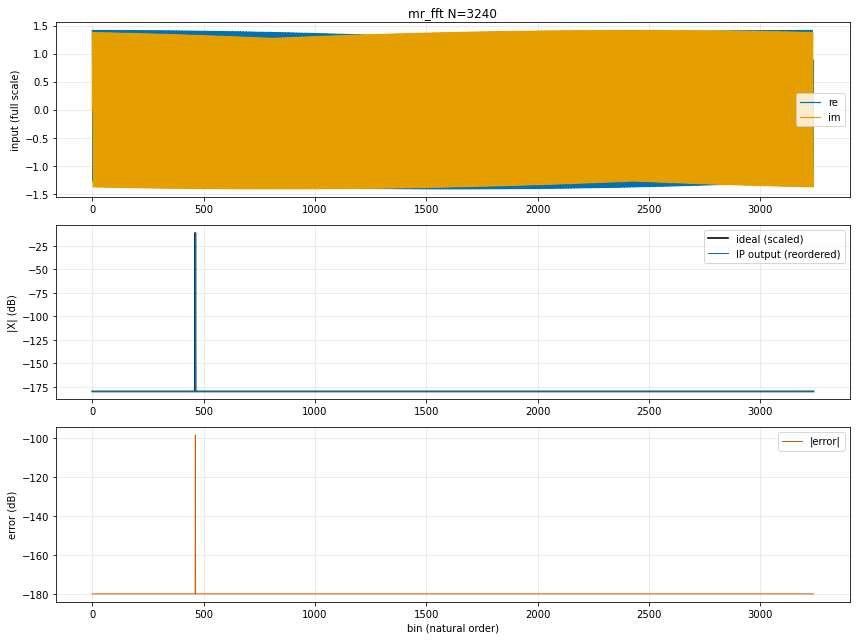

(array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]),
 array([ 3.63616446e-16-6.04644108e-17j, -1.44571583e-17+1.35114989e-16j,
         1.22380528e-16+1.57297872e-16j, ...,
         1.65794870e-16-1.82825819e-16j,  3.32148161e-16-8.13272337e-17j,
         2.37803387e-17+8.57845433e-17j]))

In [98]:
analyze(sig, fft_out, n)

In [108]:
def hw_sqnr_sweep():
    sqnr_list = []
    fft_sizes = supported_sizes()
    for size in fft_sizes:
        # Config the IP
        config_sel_write(size)
        
        sig = make_signal('tone', size)
        sig_ext = pack(sig)
        data_size = size
        input_buffer = allocate(shape=(data_size,), dtype=np.uint64)

        for i in range(data_size):
            input_buffer[i] = sig_ext[i]
            
        dma_send.transfer(input_buffer)
        output_buffer = allocate(shape=(data_size,), dtype=np.uint64)
        dma_recv.transfer(output_buffer)
        
        
        fft_out = unpack(output_buffer)
        
        meas = natural_order(fft_out[:size], size)
        ref = reference(sig, size)

        err = meas - ref
        p_ref = np.sum(np.abs(ref) ** 2)
        p_err = np.sum(np.abs(err) ** 2)
        sqnr = 10 * np.log10(p_ref / p_err) if p_err > 0 else np.inf
        print(f'N={size}: SQNR vs ideal = {sqnr:.2f} dB '
              f'(EVM ~ {100 * 10 ** (-sqnr / 20):.4f}%)')
        sqnr_list.append(sqnr)
    return sqnr_list

In [109]:
sqnr_sweep = hw_sqnr_sweep()

N=12: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=24: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=36: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=48: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=60: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=72: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=96: SQNR vs ideal = 91.62 dB (EVM ~ 0.0026%)
N=108: SQNR vs ideal = 106.91 dB (EVM ~ 0.0005%)
N=120: SQNR vs ideal = 101.65 dB (EVM ~ 0.0008%)
N=144: SQNR vs ideal = 93.13 dB (EVM ~ 0.0022%)
N=180: SQNR vs ideal = 95.95 dB (EVM ~ 0.0016%)
N=192: SQNR vs ideal = 87.63 dB (EVM ~ 0.0042%)
N=216: SQNR vs ideal = 106.91 dB (EVM ~ 0.0005%)
N=240: SQNR vs ideal = 92.23 dB (EVM ~ 0.0024%)
N=288: SQNR vs ideal = 90.68 dB (EVM ~ 0.0029%)
N=300: SQNR vs ideal = 108.71 dB (EVM ~ 0.0004%)
N=324: SQNR vs ideal = 106.91 dB (EVM ~ 0.0005%)
N=360: SQNR vs ideal = 95.95 dB (EVM ~ 0.0016%)
N=384: SQNR vs ideal = 82.98 dB (EVM ~ 0.0071%)
N=432: SQNR vs ideal = 87.57 dB (EVM ~ 0.0042%)
N=480: SQNR vs ideal = 89.48 dB (EVM

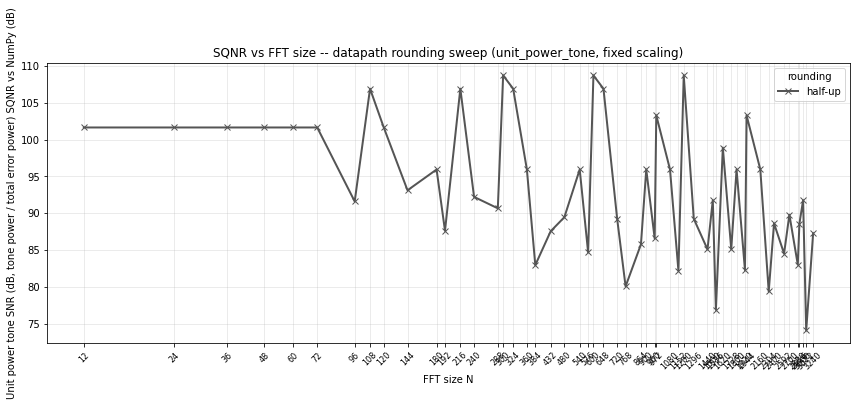

In [116]:
sizes = supported_sizes()
signal_kind = 'unit_power_tone'
scaling = 'fixed'

out_path = './hw_sqnr_sweep.png'
MODE_STYLE = {
    'floor':   ('#0072B2', 'o'),
    'around':  ('#E69F00', 's'),
    'half_up': ('#009E73', '^'),
}
ylabel = ('Unit power tone SNR (dB, tone power / total error power) SQNR vs NumPy (dB)')
fig, ax = plt.subplots(figsize=(12, 5))
modes = ['half-up']
for mode in modes:
    color, marker = MODE_STYLE.get(mode, ('#555555', 'x'))
    ax.plot(sizes, sqnr_sweep, color=color, marker=marker,
            markersize=6, linewidth=2, label=mode)
ax.set_xscale('log', base=2)
ax.set_xticks(sizes)
ax.set_xticklabels(sizes, rotation=45, fontsize=8)
ax.minorticks_off()
ax.set_title(f'SQNR vs FFT size -- datapath rounding sweep ({signal_kind}, {scaling} scaling)')
ax.set_xlabel('FFT size N')
ax.set_ylabel(ylabel)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', title='rounding')
fig.tight_layout()
fig.savefig(out_path, dpi=160)
# plt.close(fig)